<a href="https://colab.research.google.com/github/NikitaIvagin/ml-portfolio/blob/main/deployment/rest_api_neural_network/REST_API_neural_network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
import numpy as np
import keras
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

drive.mount('/content/drive')

word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}


Mounted at /content/drive


In [ ]:
dataset = np.loadtxt('https://storage.yandexcloud.net/academy.ai/A_Z_Handwritten_Data.csv', delimiter=',')

In [ ]:
X = dataset[:,1:785]
Y = dataset[:,0]

In [ ]:
# Создадим 2 выборки, чтобы перемешать данные и оставить их малую часть
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.01, shuffle=True)
del X, Y, x_train, y_train, dataset

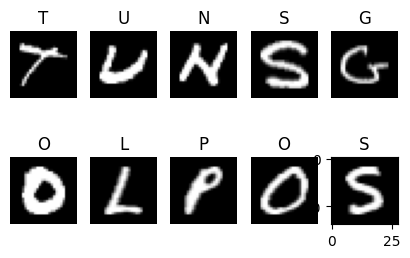

In [ ]:
# Выведем несколько букв для сравнения с результатом работы нейросети
plt.figure(figsize=(5, 3))
for i in range(10):
    x = x_test[i]
    x = x.reshape((28, 28))
    plt.axis('off')
    im = plt.subplot(2, 5, i+1)
    plt.title(word_dict.get(y_test[i]))
    im.imshow(x, cmap='gray')

In [ ]:
n = 0 # Индекс распознаваемой буквы, первые 10 букв представлены в ячейке выше
xt = np.expand_dims(x_test[n], axis=0)

In [ ]:
!pip install fastapi # Установим FastAPI
!pip install uvicorn # Установим ASGI-сервер
!pip install python-multipart # Необходимая зависимость для FastAPI (для работы с данными отправленных форм на сайте)

In [ ]:
%%writefile main.py
# импортируем FastAPI
from fastapi import FastAPI, Body
import numpy as np
import keras

model = keras.models.load_model('/content/drive/MyDrive/abc_model.h5')
word_dict = {0:'A',1:'B',2:'C',3:'D',4:'E',5:'F',6:'G',7:'H',8:'I',9:'J',10:'K',11:'L',12:'M',13:'N',14:'O',15:'P',16:'Q',17:'R',18:'S',19:'T',20:'U',21:'V',22:'W',23:'X',24:'Y',25:'Z'}

# Создаем экземпляр класса FastAPI
app = FastAPI()

# Объявляем функцию get_test() и декоратор для метода GET
@app.get("/test")
async def get_test():
    return {"Hello": "World"}

# Функция распознавания буквы
@app.post("/predict")
async def get_predict(data: dict = Body(...)):

    array_list = data.get('array')
    arr = np.array(array_list)

    prediction = model.predict(arr)
    pred = np.argmax(prediction)

    return f"Распознанная буква - {word_dict[pred]}"

Writing main.py


In [ ]:
!nohup uvicorn main:app --reload &

nohup: appending output to 'nohup.out'


In [ ]:
!cat nohup.out

In [ ]:
# Проверяем метод get
import requests
r = requests.get('http://127.0.0.1:8000/test')
print(r.status_code)
print(r.text)

200
{"Hello":"World"}


In [ ]:
# POSTим данные о букве, получаем в ответ код состояния и в случае успеха результат выполнения нейросети
data = xt.tolist()

r = requests.post('http://127.0.0.1:8000/predict', json={'array': data})
print(r.status_code)
print(r.text)

200
"Распознанная буква - T"
